In [ ]:
using JLD2
using FourierFlows
using CairoMakie
using AbstractFFTs
using Printf
using Interpolations
using LsqFit

include("./AnalysisUtils.jl")

In [2]:
sim_predicate = "/projects/rps/kss3/shaferlab/nick/2Lqg/1622258/"
fourier_predicate = "/scratch/nad9961/2LQG_fourier/"

sim_runs = ["1/", "2/", "3/", "4/", "5/", "6/", "7/"]
fourier_runs = ["1626040", "1626159", "1626245", "1626339", "1626406", "1626475", "1626592"]

7-element Vector{String}:
 "1626040"
 "1626159"
 "1626245"
 "1626339"
 "1626406"
 "1626475"
 "1626592"

In [32]:
function compute_flow_froude(run_directory, grid)
    Nsnaps = count_key_snapshots(run_directory, "2Lqg")
    t, sol = load_key_snapshot(run_directory, "2Lqg", Nsnaps)
    params = read_2Lqg_params(run_directory, "2Lqg")

    f0 = 3.0
    Cg = 1.0
    qh = 0.5 * (sol[:,:,1] - sol[:,:,2])
    ψh = @. -qh / (grid.Krsq + 2*params.F)
    uh = @. -1im * grid.l  * ψh
    vh = @.  1im * grid.kr * ψh
    vxh = 1im * grid.kr .* vh
    uyh = 1im * grid.l .* uh
    vx = irfft(vxh, grid.nx)
    uy = irfft(uyh, grid.nx)
    u = irfft(uh, grid.nx)
    v = irfft(vh, grid.nx)
    rms_u = sqrt.(sum(u.^2 + v.^2)/grid.nx/grid.ny)

    return rms_u/Cg
end

function compute_ψ_correlation(fourier_directory, grid)
    file = jldopen(@sprintf("%s/%d/radial_data_k=%03d.jld2", fourier_directory, 1, 1))
    ω_size = size(file["ψt"], 1)
    t = file["t"]
    T = t[end] - t[1]
    dt = t[2] - t[1]
    Nω = length(t)
    ωs = fftshift(fftfreq(Nω, 1/dt) * 2π)

    Ch = zeros(ω_size, 2 * grid.nkr)
    for file_idx=1:(grid.nkr-1)
        file = jldopen(@sprintf("%s/%d/radial_data_k=%03d.jld2", fourier_directory, floor(Int, (file_idx-1)/4 + 1), file_idx))
        k = file["k"]
        q = @. sqrt(k^2 + grid.l[:]^2)
        K_idx = floor.(Int, q) .+ 1
        ψt = file["ψt"]
        norm_factor = T / Nω^2 / grid.nx^2 / grid.ny^2 / 2
        # println(file_idx)
        result = real.(conj.(ψt) .* ψt) * norm_factor
        @views Ch[:, K_idx] .+= result
    end
    return ωs, Ch
end

compute_ψ_correlation (generic function with 1 method)

In [33]:
function compute_b(Ch, ωs, grid)
    Kd = 3.0
    f0 = 3.0
    c = f0 / Kd
    
    Npoints = 176
    k_max = 176
    k = (1:Npoints)/(Npoints) * k_max
    D_11_p = zeros(Npoints)
    
    ω = @. sqrt(f0^2 + c^2*k^2)
    Cg = @. c^2 * k / ω
    
    dq = 0.1
    q = 0.0:dq:grid.kr[end]
    dη = 0.01
    η = (0.0:dη:2π)'

    Ch_shifted = fftshift(Ch[:, 1:grid.nkr], 1)
    Ch_itp = extrapolate(scale(interpolate(Ch_shifted, BSpline(Cubic())), ωs, 0:(grid.nkr-1)), 0)
    
    for idx=1:Npoints
        σ = -Cg[idx] * q .* cos.(η)
        D_11_p[idx] = k[idx]^2 * sum(q.^5 .* cos.(η).^2 .* sin.(η).^2 .* Ch_itp.(σ, q) * dq * dη)
    end
    m(k, p) = p[1]*k.^2# .+ p[2]*k# .+ p[3]
    p0 = [1e-2]
    fit = curve_fit(m, k/Kd, D_11_p, p0)
    return fit.param[1]
end

compute_b (generic function with 1 method)

In [41]:
u_rmss = zeros(7)
bs = zeros(7)
for i=1:7
    run_directory = sim_predicate * sim_runs[i]
    fourier_directory = fourier_predicate * fourier_runs[i]
    nx, Lx = get_grid_size(run_directory, "2Lqg")
    grid = TwoDGrid(; nx, Lx)
    println(@sprintf("Run %d", i))
    println("====")
    flush(stdout)
    rms_u = compute_flow_froude(run_directory, grid)
    println(@sprintf("<u> = %0.3e", rms_u))
    flush(stdout)
    ωs, Ch = compute_ψ_correlation(fourier_directory, grid)
    b = compute_b(Ch, ωs, grid)
    println(@sprintf("b = %0.3e", b))
    flush(stdout)
    u_rmss[i] = rms_u
    bs[i] = b
end

Run 1
====
<u> = 8.765e-03


error in running finalizer: ErrorException("task switch not allowed from inside gc finalizer")
ijl_error at /cache/build/tester-amdci4-14/julialang/julia-release-1-dot-12/src/rtutils.c:43
ijl_switch at /cache/build/tester-amdci4-14/julialang/julia-release-1-dot-12/src/task.c:674
try_yieldto at ./task.jl:1143
wait at ./task.jl:1229
yield at ./task.jl:1084
slowlock at ./lock.jl:218
lock at ./lock.jl:195 [inlined]
close at ./iostream.jl:42
close at /ext3/pkgs/packages/JLD2/hbsZG/src/io/mmapio.jl:169 [inlined]
close at /ext3/pkgs/packages/JLD2/hbsZG/src/JLD2.jl:417
jld_finalizer at /ext3/pkgs/packages/JLD2/hbsZG/src/JLD2.jl:439
unknown function (ip: 0x14fb243b4362) at (unknown file)
run_finalizer at /cache/build/tester-amdci4-14/julialang/julia-release-1-dot-12/src/gc-common.c:180
jl_gc_run_finalizers_in_list at /cache/build/tester-amdci4-14/julialang/julia-release-1-dot-12/src/gc-common.c:270
run_finalizers at /cache/build/tester-amdci4-14/julialang/julia-release-1-dot-12/src/gc-common.c:

b = 8.743e-06
Run 2
====
<u> = 1.708e-02
b = 1.151e-04
Run 3
====
<u> = 2.659e-02
b = 3.029e-04
Run 4
====
<u> = 4.344e-02
b = 2.885e-03
Run 5
====
<u> = 5.359e-02
b = 1.135e-02
Run 6
====
<u> = 8.416e-02
b = 4.399e-02
Run 7
====
<u> = 1.118e-01
b = 5.146e-02


In [ ]:
run_directory = "/scratch/nad9961/rsw_plots/1925846/"
Nruns = 11
bs = zeros(Nruns)
u_rmss = zeros(Nruns)
for i=1:Nruns
    file = jldopen(@sprintf("%s/%d/twoL-%d.jld2", run_directory, i, i))
    println(file["b"])
    bs[i] = file["b"]
    u_rmss[i] = file["Fr"]
    close(file)
end

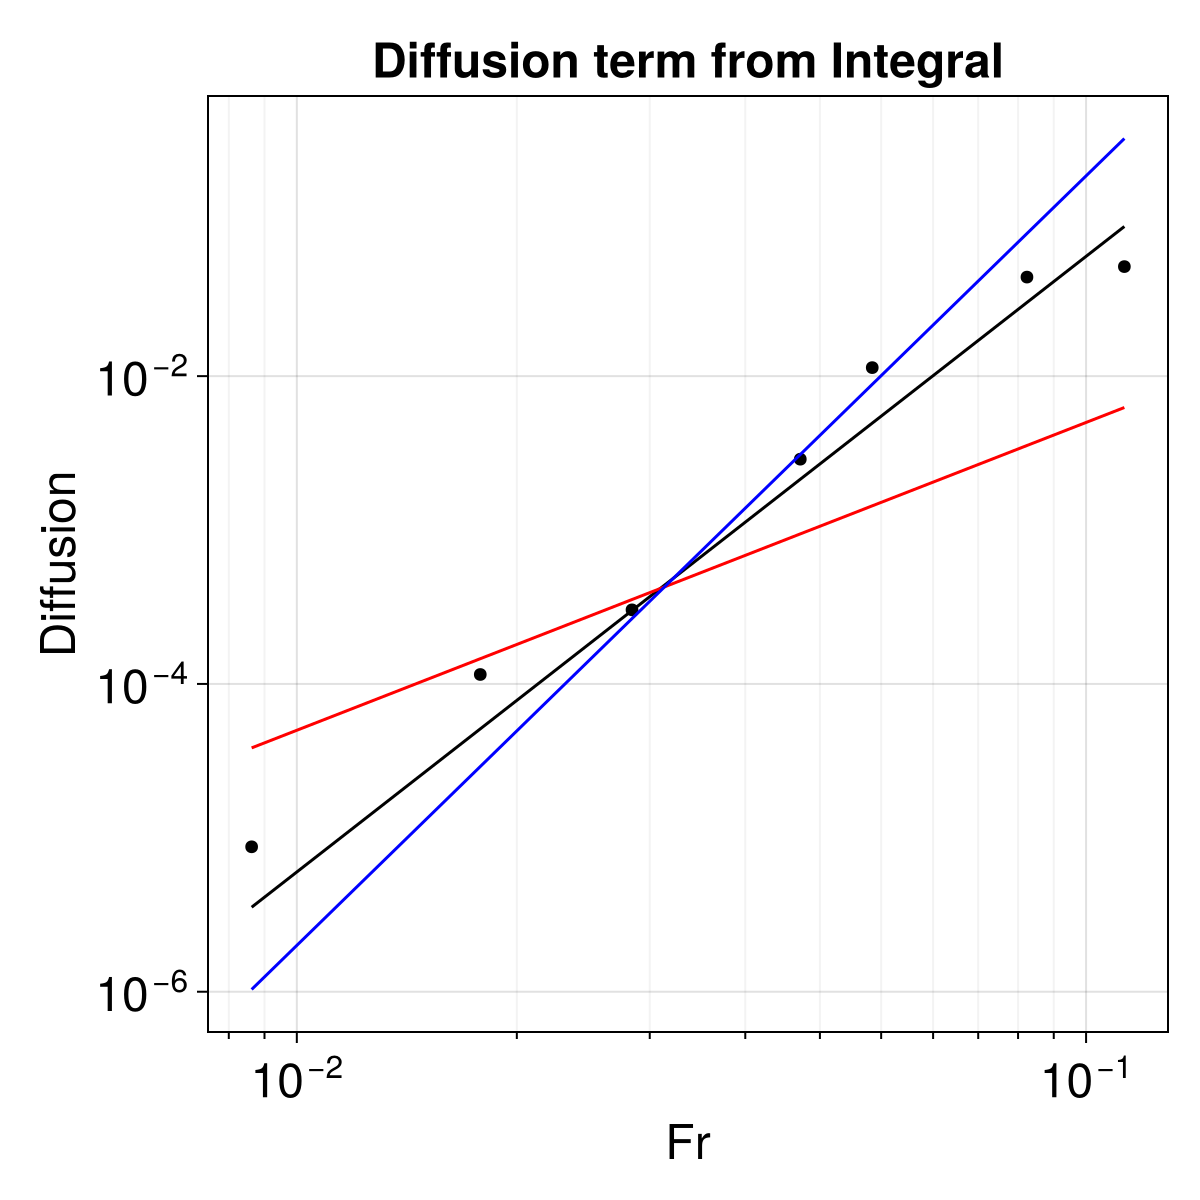

In [57]:
using CairoMakie 
fig = Figure(size=(600, 600), fontsize=24)
ax = Axis(fig[1,1]; xscale=log10, yscale=log10, xlabel="Fr", ylabel=rich("Diffusion"), title="Diffusion term from Integral",
    xticks=LogTicks(WilkinsonTicks(2; k_max=2)),
    xminorticksvisible=true,
    xminorgridvisible=true,
    xminorticks=IntervalsBetween(10)) #title=rich("Median frequency vs Fr", subscript("rms")))
scatter!(ax, u_rmss, bs, color=:black)
lines!(ax, u_rmss, 200*3*u_rmss.^4, linestyle=:solid, color=:black)
lines!(ax, u_rmss, 0.5*u_rmss.^2, linestyle=:solid, color=:red)
lines!(ax, u_rmss, 2e4*u_rmss.^5, linestyle=:solid, color=:blue)
#text!(ax, 10^(-1.25), 1e-3; text=rich("Fr", superscript("4")))
#scatter!(ax, froude_number, ωs./f0s, markersize=12, color=:red)

#save("images/froude_number_vs_median_freq.eps", fig)
fig

In [5]:
using FourierFlows
using CairoMakie

In [27]:
grid1 = OneDGrid(; Lx=2π, nx=128)
grid2 = OneDGrid(; Lx=4π, nx=256)

y1 = sin.(3 * grid1.x) + sin.(21 * grid1.x)
y2 = sin.(3 * grid2.x) + sin.(21 * grid2.x)

256-element Vector{Float64}:
 -1.2271227216937067e-15
  1.004459084455632
  1.1722059416028097
  0.47662276775769047
 -0.27589937928294406
 -0.2324303382764249
  0.6749933130331859
  1.6609361414809185
  1.8477590650225744
  1.1167617276498991
  0.22217427330945871
  0.05725139102215526
  0.7856949583871071
  ⋮
 -0.7856949583871071
 -0.05725139102215526
 -0.22217427330945871
 -1.1167617276498991
 -1.8477590650225744
 -1.6609361414809185
 -0.6749933130331859
  0.2324303382764249
  0.27589937928294406
 -0.47662276775769047
 -1.1722059416028097
 -1.004459084455632

In [28]:
y1h = rfft(y1)
y2h = rfft(y2)

C1 = abs2.(y1h)
C2 = abs2.(y2h)

129-element Vector{Float64}:
     1.5058301740969703e-30
     2.4895546548973047e-29
     7.322870751155166e-29
     7.484732319516953e-28
     2.5473110575957116e-28
     2.467338140947626e-29
 16384.000000000007
     1.0337150038682412e-27
     4.478005724297926e-29
     1.8147960928769605e-29
     6.474338243673332e-28
     3.664092742776448e-28
     1.7806854464733866e-27
     ⋮
     2.726470772288575e-28
     1.1892758915668074e-26
     2.1172333100189774e-26
     5.979057305258186e-27
     8.305046868180299e-29
     1.26295484706688e-27
     4.668163291210992e-30
     2.0854301133609184e-29
     2.793052564091682e-29
     3.973744989670113e-29
     1.7452934309703004e-28
     1.5058301740969703e-30

0.5000000000000001
0.5


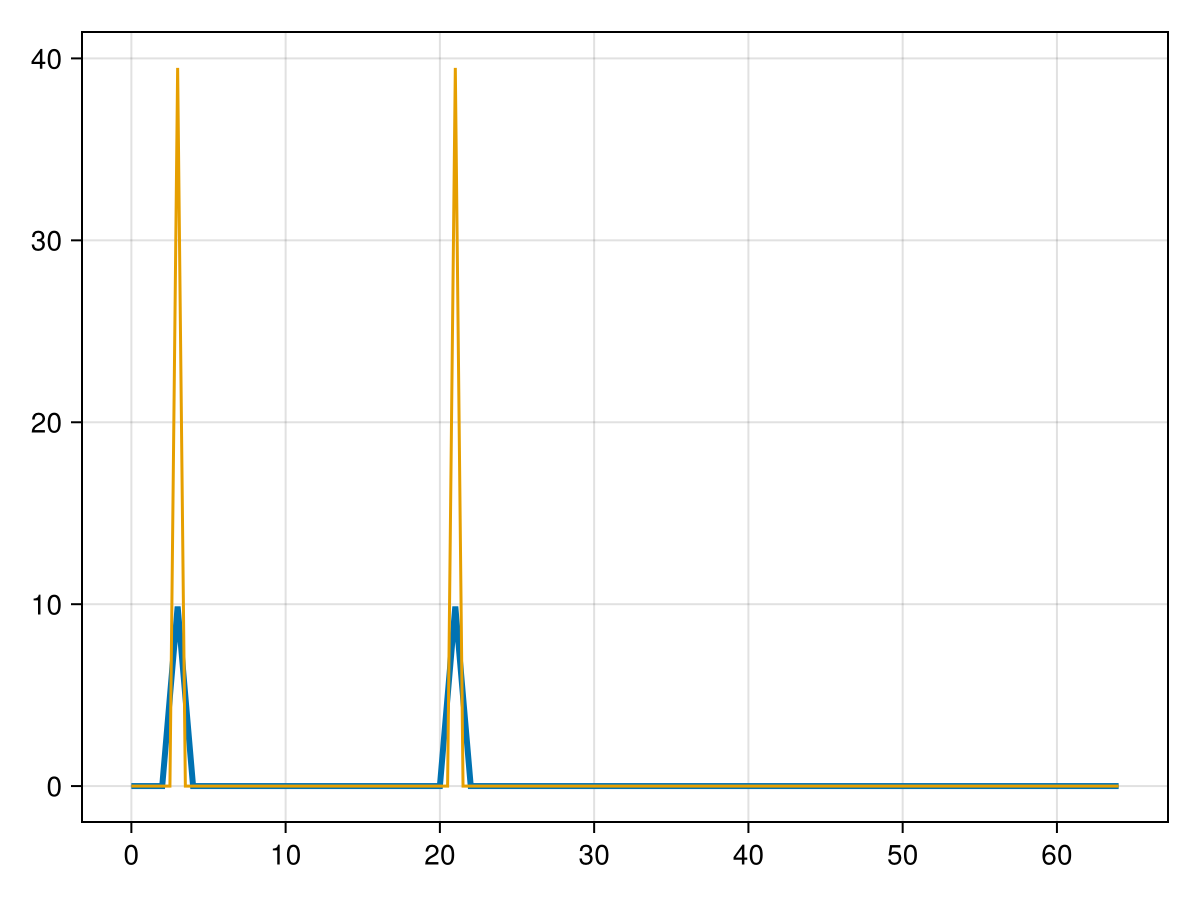

In [32]:
fig = Figure()
ax = Axis(fig[1,1])
lines!(grid1.kr, C1 * grid1.Lx^2 / grid1.nx^2, linewidth=3)
lines!(grid2.kr, C2 * grid2.Lx^2 / grid2.nx^2)

println(sum(C1 * 1 / grid1.nx^2))
println(sum(C2 * 1 / grid2.nx^2))

fig

In [6]:
y1h

65-element Vector{ComplexF64}:
 -0.7071067811865476 + 0.0im
  -0.707106781186546 + 65.84592206775943im
 -0.7071067811865475 + 16.7506802166942im
 -0.7071067811865474 + 10.226236509279197im
 -0.7071067811865479 + 7.441814442204666im
 -0.7071067811865487 + 5.8656980706405975im
 -0.7071067811865475 + 4.843141596526161im
 -0.7071067811865478 + 4.122949616714028im
 -0.7071067811865477 + 3.586795072337539im
 -0.7071067811865481 + 3.1712713943268316im
 -0.7071067811865479 + 2.839221879292767im
 -0.7071067811865474 + 2.5673836134618457im
 -0.7071067811865478 + 2.3404288999448073im
                     ⋮
 -0.7071067811865476 + 0.1957542026066812im
 -0.7071067811865475 + 0.17718482633936028im
 -0.7071067811865477 + 0.15884266851074136im
 -0.7071067811865477 + 0.1407018408556826im
 -0.7071067811865476 + 0.12273750204432865im
 -0.7071067811865475 + 0.1049257145418303im
 -0.7071067811865471 + 0.0872433115146114im
 -0.7071067811865479 + 0.0696677721522061im
 -0.7071067811865485 + 0.0521771039341834i